In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')




---



# Part 1

In [ ]:
df = pd.read_csv("/content/auto_mpg_clean.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [ ]:
print(f"""Df shape: {df.shape},
Students:         ID:
Sedra Alramadan - 2231165115
Sedra Albasha   - 2231171933
Nourhan Ismail  - 2231171917
""")


Df shape: (396, 7), 
Students:         ID:
Sedra Alramadan - 2231165115
Sedra Albasha   - 2231171933
Nourhan Ismail  - 2231171917



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           396 non-null    float64
 1   cylinders     396 non-null    int64  
 2   displacement  396 non-null    float64
 3   horsepower    396 non-null    float64
 4   weight        396 non-null    int64  
 5   acceleration  396 non-null    float64
 6   model_year    396 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 21.8 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,396.0,23.517172,7.834368,9.0,17.375,23.0,29.000,46.6
cylinders,396.0,5.457071,1.703511,3.0,4.000,4.0,8.000,8.0
displacement,396.0,193.650253,104.422387,68.0,104.750,148.5,263.250,455.0
horsepower,396.0,104.189394,38.402030,46.0,75.000,92.0,125.000,230.0
weight,396.0,2973.000000,847.690354,1613.0,2225.250,2803.5,3610.000,5140.0
acceleration,396.0,15.555808,2.758295,8.0,13.800,15.5,17.125,24.8
model_year,396.0,76.027778,3.696969,70.0,73.000,76.0,79.000,82.0


In [ ]:
print(f'Missing values: {df.isna().sum().sum()}')

Missing values: 0


In [ ]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [ ]:
y = df['mpg']
X = df.drop(columns=['mpg'])
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (396, 6), y shape: (396,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X train shape: ", X_train.shape)
print("X test shape: ", X_test.shape)
print("y train shape: ", y_train.shape)
print("y test shape: ", y_test.shape)

X train shape:  (316, 6)
X test shape:  (80, 6)
y train shape:  (316,)
y test shape:  (80,)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_lr = linear_model.predict(X_test_scaled)

KNN regressor

In [ ]:
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

Decision Tree Regressor

In [ ]:
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

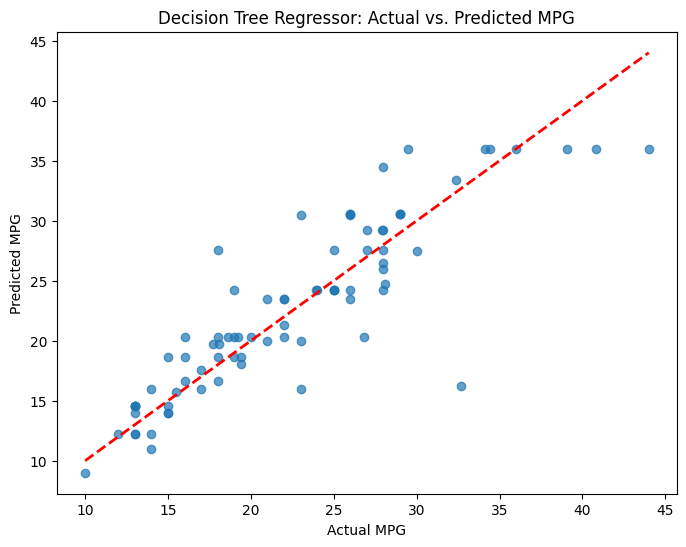

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Decision Tree Regressor: Actual vs. Predicted MPG')
plt.show()

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_dt = cross_val_score(dt, X_train, y_train, cv=kfold, scoring='r2')

print("Decision Tree Regressor - 5-fold Cross-Validation R² Scores:")
for i, score in enumerate(cv_scores_dt):
    print(f"Fold {i+1}: {score:.4f}")
print(f"Mean CV R²: {cv_scores_dt.mean():.4f}")

Decision Tree Regressor - 5-fold Cross-Validation R² Scores:
Fold 1: 0.7969
Fold 2: 0.8573
Fold 3: 0.7084
Fold 4: 0.8078
Fold 5: 0.7662
Mean CV R²: 0.7873


Models comparison

In [ ]:
eval_metrics = {
    'Linear Regression': {
        'MSE': mean_squared_error(y_test, y_pred_lr),
        'MAE': mean_absolute_error(y_test, y_pred_lr),
        'R2': r2_score(y_test, y_pred_lr),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr))
    },
    'KNN': {
        'MSE': mean_squared_error(y_test, y_pred_knn),
        'MAE': mean_absolute_error(y_test, y_pred_knn),
        'R2': r2_score(y_test, y_pred_knn),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_knn))
    },
    'Decision Tree': {
        'MSE': mean_squared_error(y_test, y_pred_dt),
        'MAE': mean_absolute_error(y_test, y_pred_dt),
        'R2': r2_score(y_test, y_pred_dt),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_dt))
    }
}

display_df = pd.DataFrame(eval_metrics)
display_df.T

,MSE,MAE,R2,RMSE
Linear Regression,10.816399,2.534837,0.791522,3.288829
KNN,7.253311,1.895714,0.860198,2.693197
Decision Tree,12.261862,2.399444,0.763662,3.501694


# Comment:
* The best performing model
across all metrics is KNN regressor. It has the lowest error in MSE, RMSE, MAE and the highest R^2 score.
* It's important to consider MAE, RMSE, and R² together because each metric provides a different perspective on the model's performance:

1. MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's robust to outliers and gives a linear score, meaning a specific error size has the same impact regardless of where it occurs. \
2. RMSE is the square root of the average of the squared errors. By squaring the errors, RMSE gives higher weight to larger errors, making it more sensitive to outliers than MAE. This can be beneficial if large errors are particularly undesirable.\
3. R² (Coefficient of Determination): represents the proportion of the variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1, and the closer to 1 the better. It helps understand how well the model explains the variability of the target variable.



---



# Part 2

In [ ]:
X_cluster = df[['horsepower', 'weight']]
X_cluster_scaled = scaler.fit_transform(X_cluster)

KMEANS Clustering

In [ ]:
results = []

for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_cluster_scaled)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_cluster_scaled, labels)
    results.append({'k': k, 'inertia': inertia, 'silhouette': silhouette})

results_df = pd.DataFrame(results)
print(results_df)

   k     inertia  silhouette
0  2  244.302946    0.616177
1  3  137.437802    0.500446
2  4   99.470380    0.481408
3  5   75.961857    0.441509


In [ ]:
best_k = results_df.loc[results_df['silhouette'].idxmax(), 'k']
print(f"Best k: {best_k}")

Best k: 2


In [ ]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df['kmeans_cluster'] = final_kmeans.fit_predict(X_cluster_scaled)
print(f"Cluster Sizes:\n{df['kmeans_cluster'].value_counts()}")

Cluster Sizes:
kmeans_cluster
0    285
1    111
Name: count, dtype: int64


In [ ]:
cluster_profile = df.groupby('kmeans_cluster')[['horsepower','weight','mpg']].mean()
print(f"Cluster Mean Profile: \n{cluster_profile}")

Cluster Mean Profile: 
                horsepower       weight        mpg
kmeans_cluster                                    
0                84.108772  2537.547368  26.841404
1               155.747748  4091.054054  14.981982


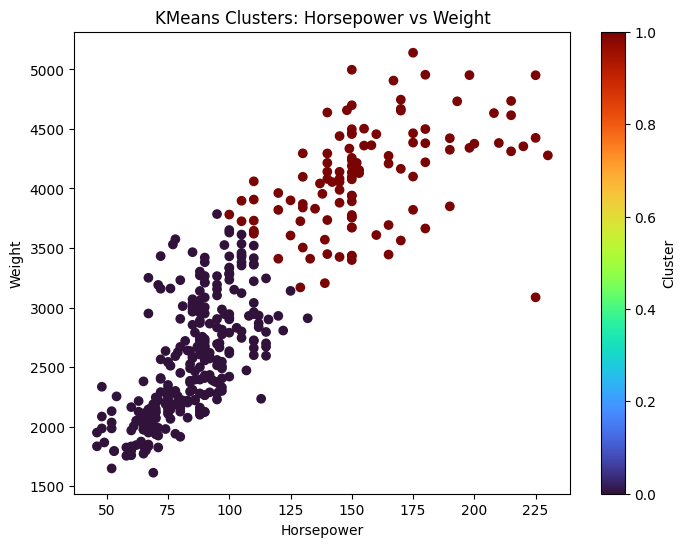

In [ ]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(df['horsepower'], df['weight'], c=df['kmeans_cluster'], cmap='turbo')
plt.title('KMeans Clusters: Horsepower vs Weight')
plt.xlabel('Horsepower')
plt.ylabel('Weight')
plt.colorbar(scatter, label='Cluster')
plt.grid(False)
plt.show()

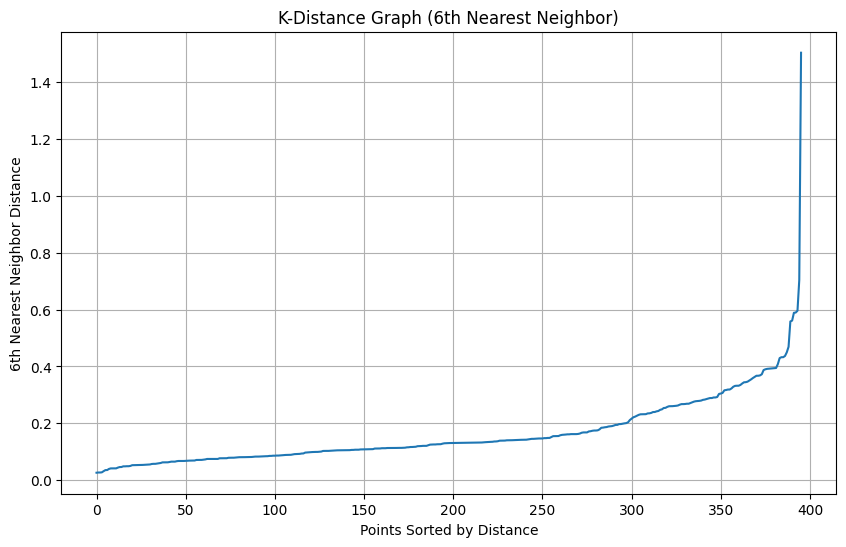

In [ ]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=6)
neighbors_fit = neighbors.fit(X_cluster_scaled)
distances, indices = neighbors_fit.kneighbors(X_cluster_scaled)

distances = np.sort(distances[:, 5], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-Distance Graph (6th Nearest Neighbor)')
plt.xlabel('Points Sorted by Distance')
plt.ylabel('6th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

DBSCAN

In [ ]:
dbscan = DBSCAN(eps=0.28, min_samples=6)
df["dbscan_cluster"] = dbscan.fit_predict(X_cluster_scaled)

dbscan_n_clusters = len(set(df["dbscan_cluster"])) - (1 if -1 in set(df["dbscan_cluster"]) else 0)

dbscan_noise_count = int((df["dbscan_cluster"] == -1).sum())

dbscan_mask = df["dbscan_cluster"] != -1
dbscan_silhouette = silhouette_score(
    X_cluster_scaled[dbscan_mask],
    df.loc[dbscan_mask, "dbscan_cluster"]
)

print(f"DBSCAN clusters found: {dbscan_n_clusters}")
print(f"Noise points found: {dbscan_noise_count}")
print(f"DBSCAN silhouette score (non-noise rows only): {dbscan_silhouette:.4f}")

print("\nCluster counts excluding noise:")
display(
    df.loc[df["dbscan_cluster"] != -1, "dbscan_cluster"]
      .value_counts()
      .sort_index()
      .rename_axis("dbscan_label")
      .to_frame(name="row_count")
)

DBSCAN clusters found: 3
Noise points found: 27
DBSCAN silhouette score (non-noise rows only): 0.5364

Cluster counts excluding noise:


,row_count
dbscan_label,
0,67
1,291
2,11


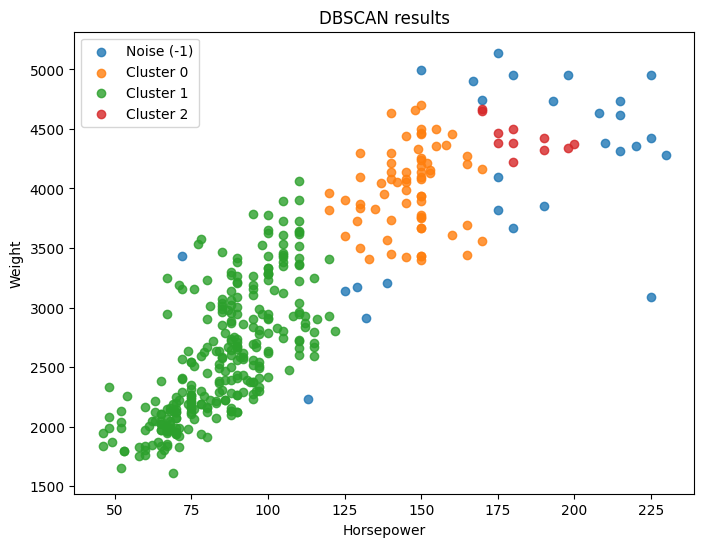

In [ ]:
plt.figure(figsize=(8, 6))

for label in sorted(df["dbscan_cluster"].unique()):
    subset = df[df["dbscan_cluster"] == label]
    if label == -1:
        label_name = "Noise (-1)"
    else:
        label_name = f"Cluster {label}"

    plt.scatter(
        subset['horsepower'],
        subset['weight'],
        alpha=0.8,
        label=label_name
    )

plt.title("DBSCAN results")
plt.xlabel('Horsepower')
plt.ylabel('Weight')
plt.legend()
plt.show()

In [ ]:
comparison_data = {
    'method': ['KMeans', 'DBSCAN'],
    'clusters_found': [best_k, dbscan_n_clusters],
    'noise_points': [0, dbscan_noise_count], # KMeans does not identify noise points
    'silhouette_score': [results_df.loc[results_df['k'] == best_k, 'silhouette'].iloc[0], dbscan_silhouette]
}

clustering_comparison_df = pd.DataFrame(comparison_data)
display(clustering_comparison_df)

,method,clusters_found,noise_points,silhouette_score
0,KMeans,2,0,0.616177
1,DBSCAN,3,27,0.536369


# Comment:
Kmeans assigns all points to clusters, giving more compact clusters (silhouette = 0.616177), while DBScan identifies noise (27 points in this case) and excludes it. It does so at a lower silhouette score (silhouette =  0.536369) but it can reveal other important information through this exclusion.